# DIGITAL TRANSACTION RISK ANALYSIS
## Unit IV: Regression Modelling (Section 5 Checklist)

For the **term-project Section 5 deliverable**, we use **one regression family only: Logistic Regression** (fraud vs non-fraud) and include:
- Baseline (no regularisation) + Regularised (L1/Lasso via GridSearchCV)
- 80/20 **stratified** train/test split + **k-fold CV (mean ± std)**
- VIF table + action if needed
- AIC/BIC via `statsmodels`
- Residual / influence diagnostics + coefficient interpretation

Plots are exported automatically into `overleaf/figures/` so they can be included in the LaTeX report.

In [19]:
# ================================================================
# SETUP: DEPENDENCIES AND DATA PREPARATION
# ================================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
    cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
    mean_squared_error,
    r2_score,
)

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from scipy import stats

RANDOM_STATE = 42
SAMPLE_PER_CLASS = 10000  # keep runtime reasonable

FIG_DIR = Path("overleaf") / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Loading dataset...")
df = pd.read_csv("fraudTrain.csv")

# Feature engineering
# (If these columns already exist from earlier units, overwriting is harmless.)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df["transaction_hour"] = df["trans_date_trans_time"].dt.hour

# Stratified sample for faster runtime.
# NOTE: Some pandas versions drop the grouping column inside .apply();
# we explicitly re-add it from the group key (g.name) to keep `is_fraud`.
df_sample = (
    df.groupby("is_fraud", group_keys=False)
    .apply(
        lambda g: g.sample(n=min(len(g), SAMPLE_PER_CLASS), random_state=RANDOM_STATE).assign(
            is_fraud=g.name
        )
    )
    .reset_index(drop=True)
)

print(f"Using stratified sample of {len(df_sample):,} records for modeling.")
print(f"Fraud rate in sample: {df_sample['is_fraud'].mean():.4f}")


Loading dataset...
Using stratified sample of 17,506 records for modeling.
Fraud rate in sample: 0.4288


## 1. Simple Linear Regression
**Objective:** Predict the transaction amount (`amt`) using a single quantitative predictor, such as `city_pop`.

In [2]:
print('\n' + '='*60)
print('SIMPLE LINEAR REGRESSION (amt vs city_pop)')
print('='*60)

X_simple = df_sample[['city_pop']]
y_simple = df_sample['amt']

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)
y_pred_simple = model_simple.predict(X_simple)

print(f"Coefficient: {model_simple.coef_[0]:.6f}")
print(f"Intercept  : {model_simple.intercept_:.2f}")
print(f"R-squared  : {r2_score(y_simple, y_pred_simple):.4f}")
print(f"MSE        : {mean_squared_error(y_simple, y_pred_simple):.2f}")



SIMPLE LINEAR REGRESSION (amt vs city_pop)
Coefficient: 0.000027
Intercept  : 264.37
R-squared  : 0.0005
MSE        : 129038.96


## 2. Multiple and Polynomial Regression
**Objective:** Predict `amt` using multiple variables and explore non-linear relationships with polynomial features.

In [3]:
print('\n' + '='*60)
print('MULTIPLE AND POLYNOMIAL REGRESSION')
print('='*60)

# Multiple Linear Regression
X_mult = df_sample[['city_pop', 'lat', 'long', 'transaction_hour']]
model_mult = LinearRegression()
model_mult.fit(X_mult, y_simple)
print(f"Multiple R-squared: {r2_score(y_simple, model_mult.predict(X_mult)):.4f}")

# Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_simple)
model_poly = LinearRegression()
model_poly.fit(X_poly, y_simple)
print(f"Polynomial R-squared (Degree 2): {r2_score(y_simple, model_poly.predict(X_poly)):.4f}")



MULTIPLE AND POLYNOMIAL REGRESSION
Multiple R-squared: 0.0619
Polynomial R-squared (Degree 2): 0.0006


## Logistic Regression for Fraud Detection (Section 5)

### 5.3.1 Model Specification (write-up)
- **Dependent variable:** `is_fraud` (1 = fraud, 0 = legitimate)
- **Predictors (start set):** `amt`, `city_pop`, `transaction_hour`, `lat`, `long`
- **Why these predictors:** Link each predictor back to Unit 3 EDA patterns and Unit 4 hypothesis tests (1–2 lines each).

### Note on sampling
To keep runtime reasonable in this notebook, we use a **stratified sample** (per-class cap). This changes the base fraud rate, so metrics should be interpreted as **model behaviour** rather than a production-ready estimate.

### 5.3.5 Coefficient Interpretation (write-up)
For the recommended model, interpret at least **three** coefficients in domain terms (logistic regression → odds/odds-ratio).

In [20]:
print("\n" + "=" * 60)
print("LOGISTIC REGRESSION (ONE FAMILY): BASELINE + REGULARISED")
print("=" * 60)

# ----------------------------------------------------------------
# 0) Model specification (dependent variable + predictors)
# ----------------------------------------------------------------
# Dependent variable (binary): is_fraud
# Predictors (numeric): amt, city_pop, transaction_hour, lat, long
# NOTE: keep this list aligned with Unit 3 EDA + Unit 4 hypothesis tests.
features = ["amt", "city_pop", "transaction_hour", "lat", "long"]

X_all = df_sample[features].copy()
y_all = df_sample["is_fraud"].astype(int)

# Defensive cleanup
X_all = X_all.replace([np.inf, -np.inf], np.nan).dropna()
y_all = y_all.loc[X_all.index]

# ----------------------------------------------------------------
# 1) Train/test split (MANDATORY: 80/20 stratified)
# ----------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Fraud rate (train): {y_train.mean():.4f} | Fraud rate (test): {y_test.mean():.4f}")

# ----------------------------------------------------------------
# 2) Baseline model (NO regularisation)
# ----------------------------------------------------------------
# scikit-learn supports penalty=None in newer versions; fallback keeps it as close as possible.
try:
    baseline_lr = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
except TypeError:
    baseline_lr = LogisticRegression(
        penalty="l2",
        C=1e6,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )

baseline_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("logreg", baseline_lr),
    ]
)

baseline_pipe.fit(X_train, y_train)

baseline_prob = baseline_pipe.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.5).astype(int)

print("Baseline fit complete.")



LOGISTIC REGRESSION (ONE FAMILY): BASELINE + REGULARISED
Train size: 14,004 | Test size: 3,502
Fraud rate (train): 0.4287 | Fraud rate (test): 0.4289
Baseline fit complete.


c:\Users\VICTUS\Desktop\Digital-Transaction-Risk-Analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## 3. Mandatory k-fold Cross-Validation (k = 5)
We report **mean ± std** for the chosen CV metric. This is required (a single train/test split is not sufficient).

In [21]:
# ---------------------------------------------------------------
# Cross-validation (MANDATORY)
# ---------------------------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

baseline_cv = cross_validate(
    baseline_pipe,
    X_train,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1,
)

def _mean_std(scores: np.ndarray) -> str:
    return f"{scores.mean():.4f} ± {scores.std():.4f}"

print("Baseline CV (train only):")
for metric_name in ["roc_auc", "accuracy", "precision", "recall", "f1"]:
    vals = baseline_cv[f"test_{metric_name}"]
    print(f"  {metric_name:>9}: {_mean_std(vals)}")


Baseline CV (train only):
    roc_auc: 0.8311 ± 0.0068
   accuracy: 0.8733 ± 0.0038
  precision: 0.9483 ± 0.0041
     recall: 0.7450 ± 0.0075
         f1: 0.8344 ± 0.0055


## 4. Multicollinearity Check (VIF)
We compute VIF for **all predictors**. Per the guide:
- VIF < 5: pass
- 5–10: borderline
- > 10: serious multicollinearity → drop/combine and re-run

In [22]:
# ---------------------------------------------------------------
# VIF table
# ---------------------------------------------------------------

def compute_vif_table(X_df: pd.DataFrame) -> pd.DataFrame:
    X_num = X_df.astype(float).copy()
    X_const = sm.add_constant(X_num, has_constant="add")
    vif_rows = []
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        vif_rows.append(
            {
                "feature": col,
                "vif": float(variance_inflation_factor(X_const.values, i)),
            }
        )
    out = pd.DataFrame(vif_rows).sort_values("vif", ascending=False).reset_index(drop=True)
    out["flag"] = np.select(
        [out["vif"] > 10, out["vif"] >= 5],
        [">10 serious", "5-10 borderline"],
        default="<5 pass",
    )
    return out

vif_table = compute_vif_table(X_train)
print("VIF table (on training predictors):")
display(vif_table)

# If serious multicollinearity exists, drop the worst offender and continue until resolved.
features_kept = features.copy()
while True:
    worst = vif_table.iloc[0]
    if worst["vif"] <= 10:
        break
    drop_feat = worst["feature"]
    print(f"Dropping '{drop_feat}' due to serious VIF = {worst['vif']:.2f}")
    features_kept.remove(drop_feat)
    vif_table = compute_vif_table(X_train[features_kept])

print(f"Final kept predictors after VIF check: {features_kept}")


VIF table (on training predictors):


,feature,vif,flag
0,amt,1.067097,<5 pass
1,transaction_hour,1.066158,<5 pass
2,city_pop,1.032572,<5 pass
3,lat,1.032492,<5 pass
4,long,1.011946,<5 pass


Final kept predictors after VIF check: ['amt', 'city_pop', 'transaction_hour', 'lat', 'long']


## 5. Regularised Model (Lasso / L1) with GridSearchCV
We tune $\lambda$ via `GridSearchCV` (in sklearn this is done by tuning `C = 1/\lambda`). We also report which coefficients were zeroed out.

In [23]:
# ---------------------------------------------------------------
# Regularised logistic regression (L1 / Lasso) + GridSearchCV
# ---------------------------------------------------------------

X_train_k = X_train[features_kept]
X_test_k = X_test[features_kept]

lasso_pipe = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                penalty="l1",
                solver="saga",
                max_iter=8000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

param_grid = {
    "logreg__C": np.logspace(-3, 2, 10),
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)

lasso_grid.fit(X_train_k, y_train)

print(f"Best C (inverse lambda): {lasso_grid.best_params_['logreg__C']}")
print(f"Best CV ROC-AUC: {lasso_grid.best_score_:.4f}")

lasso_best = lasso_grid.best_estimator_

lasso_prob = lasso_best.predict_proba(X_test_k)[:, 1]
lasso_pred = (lasso_prob >= 0.5).astype(int)

# Which features were zeroed out?
coef = lasso_best.named_steps["logreg"].coef_.ravel()
zeroed = [f for f, c in zip(features_kept, coef) if abs(c) < 1e-10]

print(f"Zeroed-out features (L1): {zeroed if zeroed else 'None'}")


Best C (inverse lambda): 0.001
Best CV ROC-AUC: 0.8320
Zeroed-out features (L1): ['city_pop', 'transaction_hour', 'lat', 'long']


c:\Users\VICTUS\Desktop\Digital-Transaction-Risk-Analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\VICTUS\Desktop\Digital-Transaction-Risk-Analysis\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 6. Model Comparison Table (Baseline vs Regularised vs CV)
We compare:
- Hold-out test metrics
- Cross-validation mean ± std (mandatory)

This is the table you can paste into the report.

In [13]:
# ---------------------------------------------------------------
# Metrics helpers + comparison table
# ---------------------------------------------------------------

def classification_metrics(y_true, y_pred, y_prob) -> dict:
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

baseline_metrics = classification_metrics(y_test, baseline_pred, baseline_prob)
lasso_metrics = classification_metrics(y_test, lasso_pred, lasso_prob)

comparison = pd.DataFrame(
    [
        {
            "model": "Baseline (no reg)",
            **baseline_metrics,
            "cv_roc_auc_mean±std": _mean_std(baseline_cv["test_roc_auc"]),
            "cv_f1_mean±std": _mean_std(baseline_cv["test_f1"]),
        },
        {
            "model": "Regularised (L1 GridSearch)",
            **lasso_metrics,
            "cv_roc_auc_mean±std": f"{lasso_grid.cv_results_['mean_test_score'][lasso_grid.best_index_]:.4f} ± {lasso_grid.cv_results_['std_test_score'][lasso_grid.best_index_]:.4f}",
            "cv_f1_mean±std": "(see per-metric CV below)",
        },
    ]
)

display(comparison)


,model,accuracy,precision,recall,f1,roc_auc,cv_roc_auc_mean±std,cv_f1_mean±std
0,Baseline (no reg),0.871216,0.937552,0.749667,0.833148,0.836580,0.8311 ± 0.0068,0.8344 ± 0.0055
1,Regularised (L1 GridSearch),0.808395,0.954098,0.581225,0.722383,0.839463,0.8320 ± 0.0067,(see per-metric CV below)


In [24]:
# Optional: full CV for the chosen regularised model across multiple metrics
lasso_cv = cross_validate(
    lasso_best,
    X_train_k,
    y_train,
    cv=cv,
    scoring=cv_scoring,
    n_jobs=-1,
)

print("Regularised (L1) CV (train only):")
for metric_name in ["roc_auc", "accuracy", "precision", "recall", "f1"]:
    vals = lasso_cv[f"test_{metric_name}"]
    print(f"  {metric_name:>9}: {_mean_std(vals)}")


Regularised (L1) CV (train only):
    roc_auc: 0.8320 ± 0.0067
   accuracy: 0.7890 ± 0.0033
  precision: 0.9571 ± 0.0022
     recall: 0.5316 ± 0.0072
         f1: 0.6836 ± 0.0063


## 7. AIC / BIC (statsmodels)
`sklearn` does not report AIC/BIC, so we fit an equivalent **unregularised** logistic regression in `statsmodels` on the same predictors to report AIC/BIC for model comparison.

In [26]:
# ---------------------------------------------------------------
# AIC / BIC from statsmodels Logit (on standardized predictors)
# ---------------------------------------------------------------

scaler_sm = StandardScaler().fit(X_train_k)
X_train_sm_arr = scaler_sm.transform(X_train_k)
X_test_sm_arr = scaler_sm.transform(X_test_k)

X_train_sm = sm.add_constant(X_train_sm_arr, has_constant="add")
X_test_sm = sm.add_constant(X_test_sm_arr, has_constant="add")

sm_logit = sm.Logit(y_train.values, X_train_sm)
sm_res = sm_logit.fit(disp=False, maxiter=200)

print(f"statsmodels Logit AIC: {sm_res.aic:.2f}")
print(f"statsmodels Logit BIC: {sm_res.bic:.2f}")

# Coefficients (standardized): interpret as 1 SD increase in predictor
index_names = ["const"] + features_kept
params = pd.Series(sm_res.params, index=index_names)
pvals = pd.Series(sm_res.pvalues, index=index_names)
conf = pd.DataFrame(sm_res.conf_int(), index=index_names, columns=["ci_low", "ci_high"])

coef_table = pd.DataFrame(
    {
        "beta": params,
        "odds_ratio": np.exp(params),
        "ci_low_or": np.exp(conf["ci_low"]),
        "ci_high_or": np.exp(conf["ci_high"]),
        "p_value": pvals,
    }
).drop(index="const")

coef_table = coef_table.sort_values("beta", key=lambda s: s.abs(), ascending=False)
print("Top coefficients by |beta| (standardized):")
display(coef_table)

# Auto-generate 3 interpretation sentences (edit wording as needed)
print("\n3 coefficient interpretations (1 SD increase, holding others constant):")
for feat in coef_table.head(3).index:
    row = coef_table.loc[feat]
    direction = "increase" if row["beta"] > 0 else "decrease"
    print(
        f"- A 1 SD increase in {feat} is associated with an {direction} in fraud odds by a factor of {row['odds_ratio']:.2f} "
        f"(OR {row['odds_ratio']:.2f}, 95% CI [{row['ci_low_or']:.2f}, {row['ci_high_or']:.2f}])."
    )


statsmodels Logit AIC: 11623.58
statsmodels Logit BIC: 11668.86
Top coefficients by |beta| (standardized):


,beta,odds_ratio,ci_low_or,ci_high_or,p_value
amt,2.771382,15.980707,14.249811,17.921852,0.000000e+00
transaction_hour,-0.152621,0.858455,0.819079,0.899725,1.882119e-10
lat,0.020612,1.020826,0.974443,1.069416,3.849768e-01
long,0.019922,1.020122,0.974383,1.068007,3.946613e-01
city_pop,0.015680,1.015804,0.969311,1.064526,5.118357e-01



3 coefficient interpretations (1 SD increase, holding others constant):
- A 1 SD increase in amt is associated with an increase in fraud odds by a factor of 15.98 (OR 15.98, 95% CI [14.25, 17.92]).
- A 1 SD increase in transaction_hour is associated with an decrease in fraud odds by a factor of 0.86 (OR 0.86, 95% CI [0.82, 0.90]).
- A 1 SD increase in lat is associated with an increase in fraud odds by a factor of 1.02 (OR 1.02, 95% CI [0.97, 1.07]).


## 8. Residual / Influence Diagnostics (Logistic)
For each plot below, add **1–2 sentences** in your report: what it tests, what you see, and whether the assumption seems reasonable.

c:\Users\VICTUS\Desktop\Digital-Transaction-Risk-Analysis\.venv\Lib\site-packages\statsmodels\discrete\discrete_model.py:5312: RuntimeWarning: divide by zero encountered in divide
  return (endog - M*p)/np.sqrt(M*p*(1-p))


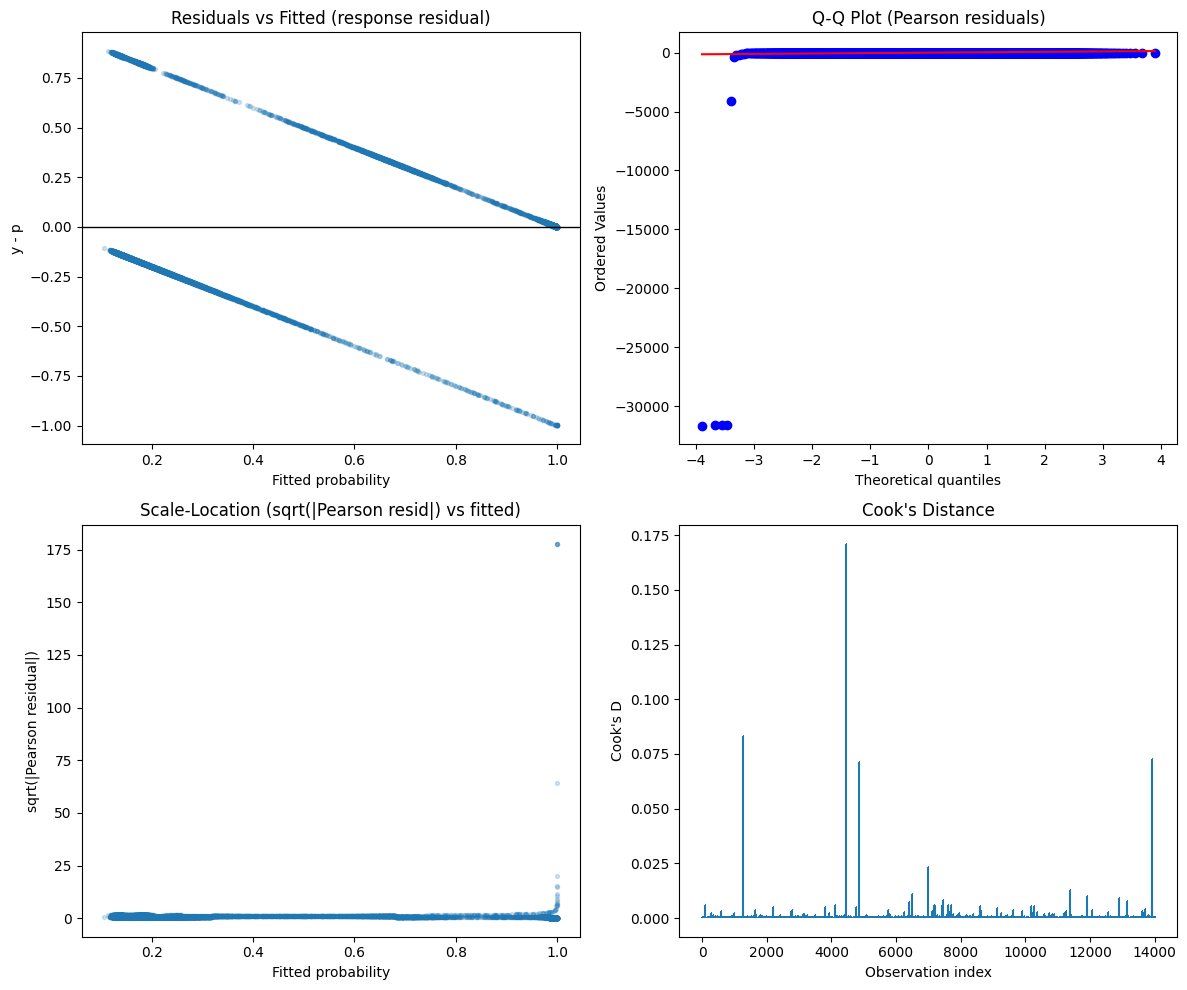

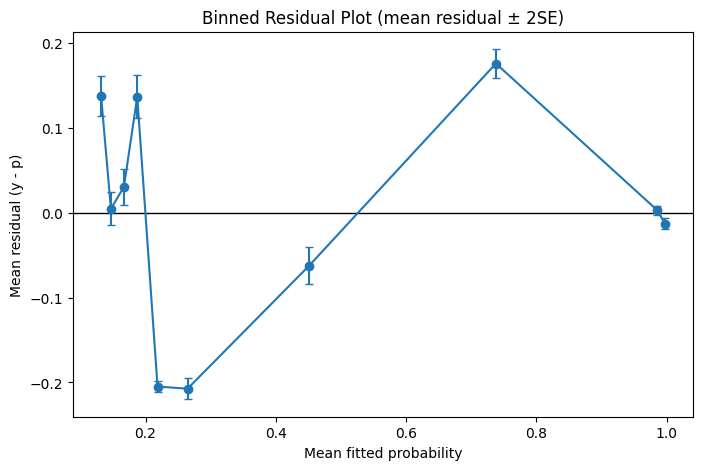

In [17]:
# ---------------------------------------------------------------
# Diagnostics plots (using statsmodels results)
# ---------------------------------------------------------------

fitted = sm_res.predict(X_train_sm)
resid_response = y_train.values - fitted

# Pearson residuals for QQ + scale-location style checks
pearson_resid = resid_response / np.sqrt(np.clip(fitted * (1 - fitted), 1e-9, None))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (1) Residual vs fitted
axes[0, 0].scatter(fitted, resid_response, alpha=0.2, s=8)
axes[0, 0].axhline(0, color="black", lw=1)
axes[0, 0].set_title("Residuals vs Fitted (response residual)")
axes[0, 0].set_xlabel("Fitted probability")
axes[0, 0].set_ylabel("y - p")

# (2) Q-Q plot (Pearson residuals)
stats.probplot(pearson_resid, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot (Pearson residuals)")

# (3) Scale-location style plot
axes[1, 0].scatter(fitted, np.sqrt(np.abs(pearson_resid)), alpha=0.2, s=8)
axes[1, 0].set_title("Scale-Location (sqrt(|Pearson resid|) vs fitted)")
axes[1, 0].set_xlabel("Fitted probability")
axes[1, 0].set_ylabel("sqrt(|Pearson residual|)")

# (4) Cook's distance (if available)
axes[1, 1].set_title("Cook's Distance")
try:
    infl = sm_res.get_influence()
    cooks_d = infl.cooks_distance[0]
    axes[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",", basefmt=" ")
    axes[1, 1].set_xlabel("Observation index")
    axes[1, 1].set_ylabel("Cook's D")
except Exception as e:
    axes[1, 1].text(0.05, 0.5, f"Cook's D not available\n({type(e).__name__}: {e})")
    axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

# Binned residual plot (useful for logistic calibration-style residual checking)
bins = pd.qcut(fitted, q=10, duplicates="drop")
resid_df = pd.DataFrame({"fitted": fitted, "resid": resid_response, "bin": bins})
binned = resid_df.groupby("bin").agg(
    fitted_mean=("fitted", "mean"),
    resid_mean=("resid", "mean"),
    resid_se=("resid", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
)

plt.figure(figsize=(8, 5))
plt.errorbar(
    binned["fitted_mean"],
    binned["resid_mean"],
    yerr=2 * binned["resid_se"],
    fmt="o-",
    capsize=3,
)
plt.axhline(0, color="black", lw=1)
plt.title("Binned Residual Plot (mean residual ± 2SE)")
plt.xlabel("Mean fitted probability")
plt.ylabel("Mean residual (y - p)")
plt.show()


## 4. Model Evaluation (Confusion Matrix and ROC Curve)
**Objective:** Evaluate the classification performance using specialized metrics.


EVALUATION METRICS (Baseline vs Regularised)


,model,accuracy,precision,recall,f1,roc_auc
0,Baseline (no reg),0.871216,0.937552,0.749667,0.833148,0.836580
1,Regularised (L1),0.808395,0.954098,0.581225,0.722383,0.839463


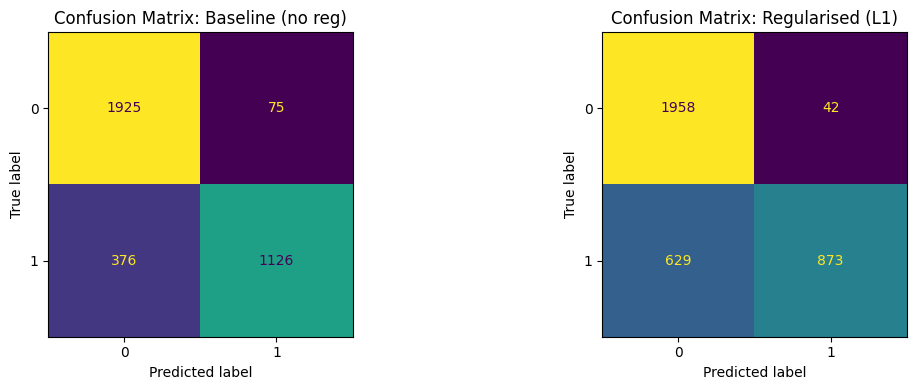

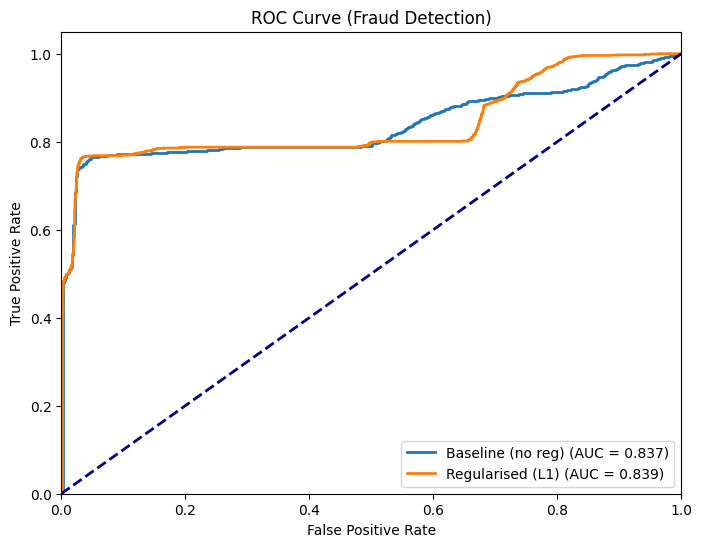

UNIT IV UPDATED: baseline + regularised + CV + VIF + AIC/BIC + diagnostics


In [18]:
print("\n" + "=" * 60)
print("EVALUATION METRICS (Baseline vs Regularised)")
print("=" * 60)

models = {
    "Baseline (no reg)": (baseline_pred, baseline_prob),
    "Regularised (L1)": (lasso_pred, lasso_prob),
}

metric_rows = []
for name, (pred, prob) in models.items():
    row = {"model": name, **classification_metrics(y_test, pred, prob)}
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows)
display(metrics_df)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, (pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
plt.tight_layout()
plt.show()

# ROC curves (overlay)
plt.figure(figsize=(8, 6))
for name, (_, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title("ROC Curve (Fraud Detection)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("=" * 60)
print("UNIT IV UPDATED: baseline + regularised + CV + VIF + AIC/BIC + diagnostics")
print("=" * 60)
